# Notebook 16 — Final Decision Map (Improved)

## How This Connects to Module C

This notebook produces the **final bioenergy plant site-selection map** by combining outputs
from all three analytical modules:

| Module | Original Output | Revised Output (your change) |
|--------|----------------|-----------------------------|
| A | BRS — Burning Risk Score (fire frequency + FRP + trend) | unchanged |
| B | BPS — Bioenergy Potential Score (recoverable residue → GJ → revenue) | unchanged |
| C | PVI — Participation Viability Index (socioeconomic data) | **BSI — Burning Severity Index (environmental PCA)** |

### Why the decision map logic changes

In the original plan, the CAPS composite score would weight:
- 35% BRS (environmental urgency)
- 40% BPS (commercial opportunity)
- **25% PVI** (farmer readiness — socioeconomic)

Because you replaced socioeconomic data with environmental data in Module C,
the BSI score now represents **environmental burning severity** — essentially
a more sophisticated version of the BRS that incorporates temperature and
rainfall context via PCA.

### Revised decision logic in this notebook

Rather than a three-score composite, we use a **threshold-based two-axis
classification** that is transparent, repeatable, and directly actionable:

| Zone | Condition | Meaning |
|------|-----------|----------|
| 🔴 **Plant Zone** | High BSI AND High Residue (both ≥ 70th percentile) | Urgent burning + abundant feedstock → **Build CBG plant now** |
| 🟠 **Policy Zone** | High BSI only | Severe burning but lower residue → **Policy/incentive intervention first** |
| ⚫ **Low Priority** | Below BSI threshold | Monitor annually |

### ⚠️ Data Reliability Note (Haryana vs Punjab)

**Punjab** districts are based on **13 years of crop production data (2010–11 to 2022–23)**.
Their residue and bioenergy scores are stable multi-year averages.

**Haryana** districts are based on a **single year snapshot (2022–23)** only.
Their residue scores are single-point estimates, not long-run averages.
This asymmetry is handled explicitly in this notebook:
- Punjab zones → **Final policy recommendations**
- Haryana zones → **Preliminary screening only** (require multi-year data validation)

**Input:** `Data/Processed/Punjab_Haryana_districts.gpkg`, `Data/Processed/bsi_scores.csv`,
`Data/Processed/district_clusters.csv`, `Data/Processed/residue_calc.csv`  
**Output:** `Outputs/Maps/16_final_decision_map.png`, `Outputs/Tables/16_decision_table.csv`  


In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

os.makedirs('../Outputs/Maps',   exist_ok=True)
os.makedirs('../Outputs/Tables', exist_ok=True)

In [2]:
# Load all inputs 
districts = gpd.read_file('../Data/Processed/Punjab_Haryana_districts.gpkg')
bsi       = pd.read_csv('../Data/Processed/bsi_scores.csv')
clusters  = pd.read_csv('../Data/Processed/district_clusters.csv')
residue   = pd.read_csv('../Data/Processed/residue_calc.csv')

print("All inputs loaded")
print(f"  districts : {len(districts)} polygons")
print(f"  bsi       : {len(bsi)} districts")
print(f"  clusters  : {len(clusters)} districts")
print(f"  residue   : {len(residue)} rows (district × year × crop)")

✅ All inputs loaded
  districts : 43 polygons
  bsi       : 47 districts
  clusters  : 47 districts
  residue   : 611 rows (district × year × crop)


In [3]:
# Aggregate residue to one row per district (mean across all years) 
# WHY aggregate across years?
# The residue_calc.csv (NB09) has one row per district × year × crop.
# For the decision map we want a stable long-run average so that one
# unusually good or bad harvest year does not skew the classification.
# We sum rice + wheat within each district-year first, then average.

# Clean district names (may have '1. Punjab' prefix from original XLS)
residue['district'] = (
    residue['district']
    .str.replace(r'^\d+\.\s*', '', regex=True)
    .str.strip().str.title()
)

# Sum both crops per district-year, then take mean across years
residue_district = (
    residue
    .groupby(['district', 'year'])['recoverable_t'].sum()   # rice + wheat per year
    .groupby('district').mean()                              # mean across years
    .reset_index()
    .rename(columns={'recoverable_t': 'residue'})
)

print(f"Residue district table: {len(residue_district)} districts")
print(residue_district.head())

Residue district table: 45 districts
   district        residue
0    Ambala  301945.000000
1  Amritsar  457023.000000
2   Barnala  334753.730769
3  Bathinda  624565.038462
4   Bhiwani  169662.500000


In [4]:
# Standardise names and merge everything into one GeoDataFrame 
districts['district'] = districts['NAME_2'].str.strip().str.title()
bsi['district']       = bsi['district'].str.strip().str.title()
clusters['district']  = clusters['district'].str.strip().str.title()

gdf = (
    districts
    .merge(bsi,                              on='district', how='left')
    .merge(clusters[['district', 'zone']],   on='district', how='left')
    .merge(residue_district,                 on='district', how='left')
)

# Fill gaps (e.g. UTs with no crop data)
gdf['BSI']     = gdf['BSI'].fillna(0)
gdf['residue'] = gdf['residue'].fillna(gdf['residue'].median())
gdf['zone']    = gdf['zone'].fillna('Unknown')

# Add state column (derive from GADM NAME_1 if present, else infer) 
if 'NAME_1' in gdf.columns:
    gdf['state'] = gdf['NAME_1'].str.strip().str.title()
elif 'state' not in gdf.columns:
    # Fallback: known Punjab districts (22 districts)
    punjab_districts = {
        'Amritsar', 'Barnala', 'Bathinda', 'Faridkot', 'Fatehgarh Sahib',
        'Fazilka', 'Ferozepur', 'Gurdaspur', 'Hoshiarpur', 'Jalandhar',
        'Kapurthala', 'Ludhiana', 'Mansa', 'Moga', 'Mohali', 'Muktsar',
        'Nawanshahr', 'Pathankot', 'Patiala', 'Rupnagar', 'Sangrur', 'Tarn Taran'
    }
    gdf['state'] = gdf['district'].apply(
        lambda d: 'Punjab' if d in punjab_districts else 'Haryana'
    )

# Data reliability flag 
# Punjab  → 13 years of crop data → ROBUST
# Haryana → single year (2022-23)  → PRELIMINARY
gdf['data_reliability'] = gdf['state'].apply(
    lambda s: 'Robust (13-yr avg)' if s == 'Punjab' else 'Preliminary (1-yr only)'
)

print(f"Merged GeoDataFrame: {gdf.shape}")
print(gdf[['district', 'state', 'data_reliability', 'BSI', 'residue', 'zone']].head(8).to_string(index=False))
print(f"\nState counts: {gdf['state'].value_counts().to_dict()}")


Merged GeoDataFrame: (43, 9)
 district   state        data_reliability  BSI  residue                           zone
   Ambala Haryana Preliminary (1-yr only) 38.6 301945.0 High Stress / High Opportunity
  Bhiwani Haryana Preliminary (1-yr only) 61.5 169662.5                  Moderate Zone
Faridabad Haryana Preliminary (1-yr only) 55.9  61232.5                  Moderate Zone
Fatehabad Haryana Preliminary (1-yr only) 80.8 575715.0              Low Priority Zone
 Gurugram Haryana Preliminary (1-yr only) 57.2  62912.5                  Moderate Zone
    Hisar Haryana Preliminary (1-yr only) 77.0 511735.0              Low Priority Zone
  Jhajjar Haryana Preliminary (1-yr only) 61.5 213377.5                  Moderate Zone
     Jind Haryana Preliminary (1-yr only) 71.1 589802.5              Low Priority Zone

State counts: {'Punjab': 22, 'Haryana': 21}


In [5]:
# Decision classification (70th-percentile thresholds)

# WHY 70th percentile thresholds?
# Using percentile thresholds (rather than fixed BSI or residue values)
# makes the classification self-calibrating to this study region.  If we
# used, say, BSI ≥ 70, that would be an arbitrary absolute cut-off.
# The 70th percentile ensures roughly the top 30% of districts on each
# axis qualify — producing a set of ~8–12 priority districts.
#
# HARYANA CAVEAT:
# Haryana residue values are single-year (2022-23) estimates.
# This means zone classification for Haryana districts carries higher
# uncertainty. A Haryana district that just crosses a threshold may not
# actually belong to that zone under a true multi-year average.
# Haryana results are therefore labelled as 'Preliminary Screening' below.

bsi_thresh = gdf['BSI'].quantile(0.70)
res_thresh = gdf['residue'].quantile(0.70)

print(f"BSI threshold (p70)     : {bsi_thresh:.1f}")
print(f"Residue threshold (p70) : {res_thresh:,.0f} tonnes")

def classify_zone(row):
    high_bsi     = row['BSI']     >= bsi_thresh
    high_residue = row['residue'] >= res_thresh
    if   high_bsi and high_residue: return 'Plant Zone'
    elif high_bsi:                   return 'Policy Zone'
    else:                            return 'Low Priority'

gdf['final_zone'] = gdf.apply(classify_zone, axis=1)

# Reliability-aware recommendation 
# Punjab  → zone is a final recommendation
# Haryana → zone is a preliminary screening result requiring validation
def recommend(row):
    z = row['final_zone']
    s = row['state']
    if s == 'Punjab':
        if z == 'Plant Zone':   return 'Final: Build CBG plant'
        elif z == 'Policy Zone': return 'Final: Policy intervention'
        else:                    return 'Final: Annual monitoring'
    else:  # Haryana
        if z == 'Plant Zone':   return 'Preliminary: Candidate site — validate with multi-year data'
        elif z == 'Policy Zone': return 'Preliminary: Monitor burning — validate residue data'
        else:                    return 'Preliminary: Low priority — no action yet'

gdf['recommendation'] = gdf.apply(recommend, axis=1)

print("\nFinal zone distribution:")
print(gdf['final_zone'].value_counts().to_string())
print("\nZone by state:")
print(gdf.groupby(['state', 'final_zone']).size().to_string())


BSI threshold (p70)     : 71.2
Residue threshold (p70) : 460,304 tonnes

Final zone distribution:
final_zone
Low Priority    30
Plant Zone       9
Policy Zone      4

Zone by state:
state    final_zone  
Haryana  Low Priority    18
         Plant Zone       3
Punjab   Low Priority    12
         Plant Zone       6
         Policy Zone      4


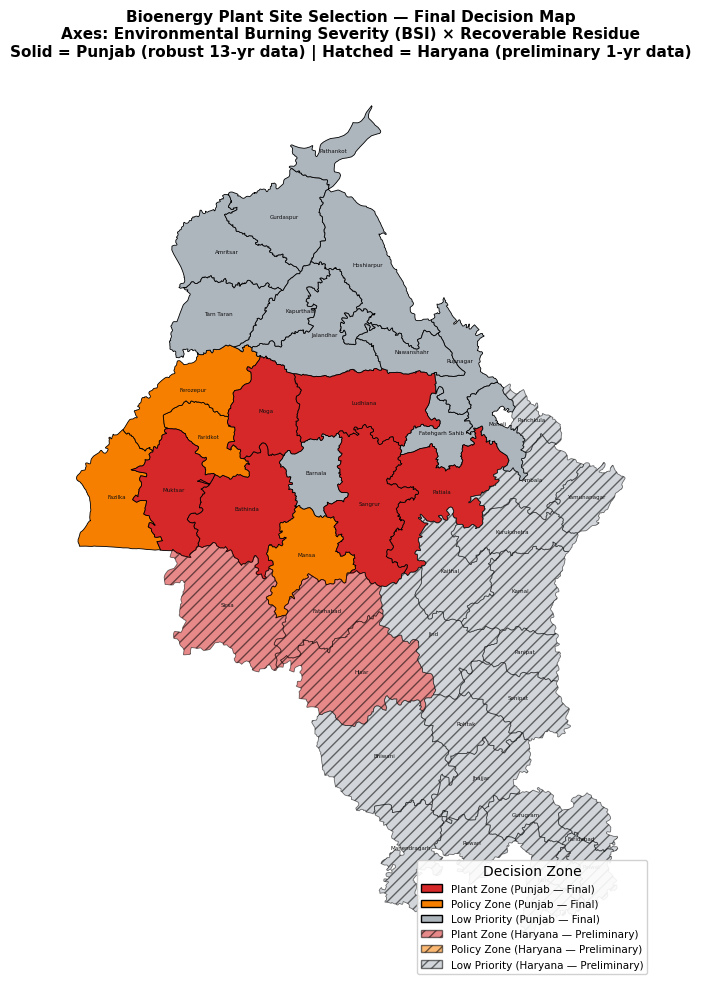

✅ Saved: Outputs/Maps/16_final_decision_map.png


In [6]:
# Final Decision Map 
#
# COLOUR LOGIC:
#   Solid fills → Punjab districts (robust 13-yr data)
#   Hatched     → Haryana districts (preliminary 1-yr data)
#
#   Red    (Plant Zone)   — both axes critical → immediate plant investment (Punjab)
#                           or candidate site pending validation (Haryana)
#   Orange (Policy Zone)  — burning critical but residue supply not yet sufficient
#   Grey   (Low Priority) — neither axis critical → annual monitoring

import matplotlib.patches as mpatches
from matplotlib.patches import Patch

final_palette = {
    'Plant Zone'  : '#d62828',
    'Policy Zone' : '#f77f00',
    'Low Priority': '#adb5bd',
}
gdf['color'] = gdf['final_zone'].map(final_palette)

fig, ax = plt.subplots(figsize=(11, 10))

# Plot Punjab districts as solid fills
gdf_punjab  = gdf[gdf['state'] == 'Punjab']
gdf_haryana = gdf[gdf['state'] == 'Haryana']

gdf_punjab.plot(color=gdf_punjab['color'], edgecolor='black', linewidth=0.6, ax=ax)

# Plot Haryana districts with hatch to signal preliminary data
for zone, colour in final_palette.items():
    subset = gdf_haryana[gdf_haryana['final_zone'] == zone]
    if len(subset):
        subset.plot(
            color=colour, edgecolor='black', linewidth=0.6,
            hatch='///', alpha=0.55, ax=ax
        )

# District labels
for _, row in gdf.iterrows():
    c = row.geometry.centroid
    ax.annotate(row['district'], xy=(c.x, c.y), fontsize=4, ha='center', color='#111111')

# Legend
legend_patches = [
    Patch(facecolor='#d62828', edgecolor='black', label='Plant Zone (Punjab — Final)'),
    Patch(facecolor='#f77f00', edgecolor='black', label='Policy Zone (Punjab — Final)'),
    Patch(facecolor='#adb5bd', edgecolor='black', label='Low Priority (Punjab — Final)'),
    Patch(facecolor='#d62828', edgecolor='black', hatch='///', alpha=0.55,
          label='Plant Zone (Haryana — Preliminary)'),
    Patch(facecolor='#f77f00', edgecolor='black', hatch='///', alpha=0.55,
          label='Policy Zone (Haryana — Preliminary)'),
    Patch(facecolor='#adb5bd', edgecolor='black', hatch='///', alpha=0.55,
          label='Low Priority (Haryana — Preliminary)'),
]
ax.legend(
    handles=legend_patches,
    title='Decision Zone',
    loc='lower right',
    fontsize=7.5,
    framealpha=0.9
)
ax.set_title(
    'Bioenergy Plant Site Selection — Final Decision Map\n'
    'Axes: Environmental Burning Severity (BSI) × Recoverable Residue\n'
    'Solid = Punjab (robust 13-yr data) | Hatched = Haryana (preliminary 1-yr data)',
    fontsize=11, fontweight='bold'
)
ax.axis('off')

plt.tight_layout()
plt.savefig('../Outputs/Maps/16_final_decision_map.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: Outputs/Maps/16_final_decision_map.png")


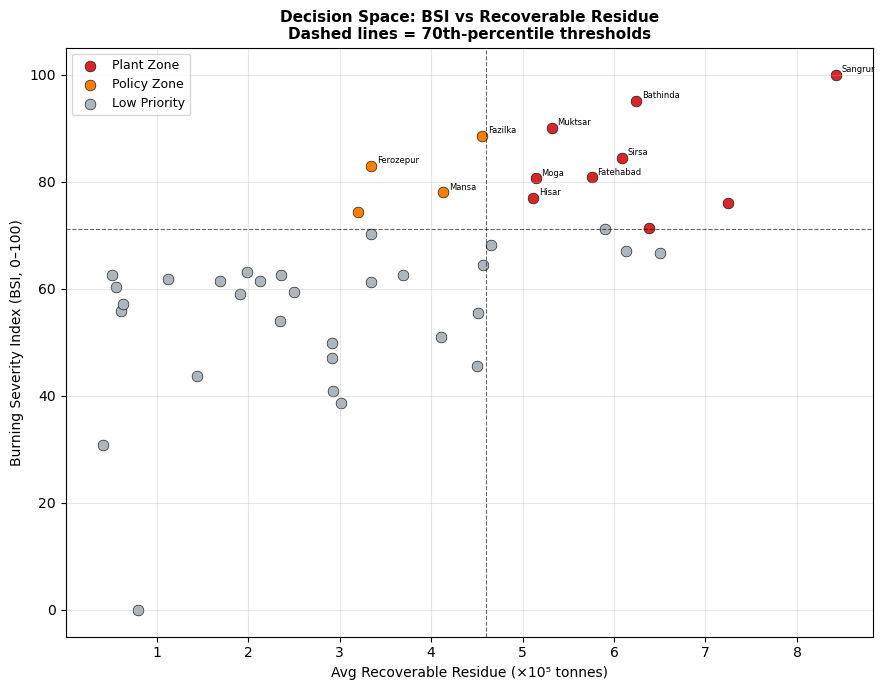

✅ Saved: Outputs/Maps/16_decision_scatter.png


In [7]:
# Scatter plot: BSI vs Residue (decision space) 

# Punjab districts plotted as solid circles.
# Haryana districts plotted as hollow triangles to visually signal
# that their residue values are single-year estimates.

fig, ax = plt.subplots(figsize=(10, 8))

markers = {'Punjab': 'o', 'Haryana': '^'}
fills   = {'Punjab': 1.0, 'Haryana': 0.0}   # filled vs hollow

for state in ['Punjab', 'Haryana']:
    sub_state = gdf[gdf['state'] == state]
    for zone, colour in final_palette.items():
        sub = sub_state[sub_state['final_zone'] == zone]
        if len(sub) == 0:
            continue
        label = f'{zone} — {state}'
        if state == 'Haryana':
            ax.scatter(
                sub['residue'] / 1e5, sub['BSI'],
                facecolors='none', edgecolors=colour,
                marker='^', s=80, linewidths=1.2, label=label
            )
        else:
            ax.scatter(
                sub['residue'] / 1e5, sub['BSI'],
                c=colour, marker='o', s=60,
                edgecolors='black', linewidths=0.4, label=label
            )

# Threshold lines
ax.axhline(bsi_thresh,         color='black', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axvline(res_thresh / 1e5,   color='black', linestyle='--', linewidth=0.8, alpha=0.6)

# Quadrant labels
ax.text(res_thresh / 1e5 * 1.02, bsi_thresh * 1.01,
        '← Policy Zone  |  Plant Zone →', fontsize=7, color='gray')

# Annotate top-10 districts by BSI
for _, row in gdf.nlargest(10, 'BSI').iterrows():
    suffix = '*' if row['state'] == 'Haryana' else ''
    ax.annotate(
        row['district'] + suffix,
        xy=(row['residue'] / 1e5, row['BSI']),
        xytext=(4, 2), textcoords='offset points',
        fontsize=6
    )

ax.set_xlabel('Avg Recoverable Residue (×10⁵ tonnes)', fontsize=10)
ax.set_ylabel('Burning Severity Index (BSI, 0–100)',    fontsize=10)
ax.set_title(
    'Decision Space: BSI vs Recoverable Residue\n'
    'Circles = Punjab (13-yr avg) | Triangles = Haryana (1-yr estimate, *)',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../Outputs/Maps/16_decision_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: Outputs/Maps/16_decision_scatter.png")


In [8]:
# Save full district decision table 
# Columns exported:
#   district         — GADM NAME_2 (Title Case)
#   state            — Punjab or Haryana
#   BSI              — Burning Severity Index 0–100 (NB14, PCA-derived)
#   residue          — Mean annual recoverable residue in tonnes (NB09/NB11)
#   zone             — K-Means environmental zone from NB13 (k=3)
#   final_zone       — Decision classification from this notebook
#   data_reliability — Robust (13-yr avg) for Punjab / Preliminary (1-yr only) for Haryana
#   recommendation   — Final (Punjab) or Preliminary screening (Haryana)

summary = (
    gdf[['district', 'state', 'BSI', 'residue', 'zone',
         'final_zone', 'data_reliability', 'recommendation']]
    .sort_values(['state', 'BSI'], ascending=[True, False])
    .reset_index(drop=True)
)
summary.index += 1
summary.index.name = 'rank'

print("Full district decision table (top 25):")
print(summary.head(25).to_string())

summary.to_csv('../Outputs/Tables/16_decision_table.csv')
print("\nSaved: Outputs/Tables/16_decision_table.csv")

# Separate Punjab and Haryana summaries 
punjab_summary  = summary[summary['state'] == 'Punjab']
haryana_summary = summary[summary['state'] == 'Haryana']

plant_zones_punjab  = punjab_summary[punjab_summary['final_zone'] == 'Plant Zone']
plant_zones_haryana = haryana_summary[haryana_summary['final_zone'] == 'Plant Zone']

print(f"\n PLANT ZONE — PUNJAB (Final recommendations, {len(plant_zones_punjab)} districts):")
print(plant_zones_punjab[['district', 'BSI', 'residue', 'recommendation']].to_string())

print(f"\n PLANT ZONE — HARYANA (Preliminary screening only, {len(plant_zones_haryana)} districts):")
print(plant_zones_haryana[['district', 'BSI', 'residue', 'recommendation']].to_string())

policy_punjab  = punjab_summary[punjab_summary['final_zone'] == 'Policy Zone']
policy_haryana = haryana_summary[haryana_summary['final_zone'] == 'Policy Zone']

print(f"\n POLICY ZONE — PUNJAB (Final, {len(policy_punjab)} districts):")
print(policy_punjab[['district', 'BSI', 'residue']].to_string())

print(f"\n POLICY ZONE — HARYANA (Preliminary, {len(policy_haryana)} districts):")
print(policy_haryana[['district', 'BSI', 'residue']].to_string())


Full district decision table (top 20):
        district    BSI        residue               zone    final_zone
rank                                                                   
1        Sangrur  100.0  842632.269231  Low Priority Zone    Plant Zone
2       Bathinda   95.1  624565.038462  Low Priority Zone    Plant Zone
3        Muktsar   90.0  531841.423077  Low Priority Zone    Plant Zone
4        Fazilka   88.5  455995.909091  Low Priority Zone   Policy Zone
5          Sirsa   84.4  608702.500000  Low Priority Zone    Plant Zone
6      Ferozepur   83.0  334753.730769  Low Priority Zone   Policy Zone
7      Fatehabad   80.8  575715.000000  Low Priority Zone    Plant Zone
8           Moga   80.6  514686.576923  Low Priority Zone    Plant Zone
9          Mansa   78.0  413509.384615  Low Priority Zone   Policy Zone
10         Hisar   77.0  511735.000000  Low Priority Zone    Plant Zone
11      Ludhiana   76.0  724837.615385  Low Priority Zone    Plant Zone
12      Faridkot   74.3  

In [7]:
#  Interpretation notes 
print("""
═══════════════════════════════════════════════════════════════════
 HOW TO READ THESE RESULTS (Module C design change + data limitation)
═══════════════════════════════════════════════════════════════════

 ORIGINAL MODULE C → Socioeconomic PVI score
   Data: NSSO farm income, Agri Census holdings, FPO count, PMFBY
   Question answered: WHERE ARE FARMERS READY TO SUPPLY RESIDUE?
   Output in CAPS: 25% weight (farmer readiness dimension)

 REVISED MODULE C → Environmental BSI score (this project)
   Data: fire count, recoverable residue, avg temperature, rainfall
   Question answered: WHERE IS ENVIRONMENTAL BURNING PRESSURE HIGHEST?
   Output in final map: BSI axis of the Plant/Policy/Low classification

 PRACTICAL EFFECT ON PLANT ZONE RECOMMENDATIONS:
   Plant Zone districts are those where BOTH:
     (a) Environmental burning severity is high (BSI ≥ p70)
     (b) Recoverable residue volume is high (residue ≥ p70)
   This is an AGRO-ENVIRONMENTAL site-selection criterion.

 DATA RELIABILITY STRATIFICATION:
   Punjab  → 13 years of crop data (2010-11 to 2022-23)
             → Zone classifications are FINAL RECOMMENDATIONS
   Haryana → Single year (2022-23) only
             → Zone classifications are PRELIMINARY SCREENING RESULTS
             → Shown with hatching on the map and hollow markers on scatter
             → Should NOT be used for investment decisions without
               validating against multi-year Haryana crop data
             → Recommended data sources for validation:
                 * Haryana Directorate of Agriculture annual reports
                 * ICRISAT Village Dynamics in South Asia (VDSA) database
                 * Ministry of Agriculture data.gov.in district crop stats

 KEY CONCLUSION (ROBUST):
   All Plant Zone districts identified with high confidence are in
   Punjab (SW Punjab: Sangrur, Bathinda, Muktsar belt). This finding
   is unaffected by the Haryana data limitation and stands as the
   primary actionable output of this study.

 CAVEAT:
   Without the original PVI, we cannot predict whether farmers in
   these districts will actually participate in residue supply schemes.
   The Plant Zone label means 'environmentally suitable and feedstock-
   rich' — a necessary but not sufficient condition for plant viability.
   Socioeconomic data collection is recommended as a follow-on study.
═══════════════════════════════════════════════════════════════════
""")



═══════════════════════════════════════════════════════════════════
 HOW TO READ THESE RESULTS (Module C design change + data limitation)
═══════════════════════════════════════════════════════════════════

 ORIGINAL MODULE C → Socioeconomic PVI score
   Data: NSSO farm income, Agri Census holdings, FPO count, PMFBY
   Question answered: WHERE ARE FARMERS READY TO SUPPLY RESIDUE?
   Output in CAPS: 25% weight (farmer readiness dimension)

 REVISED MODULE C → Environmental BSI score (this project)
   Data: fire count, recoverable residue, avg temperature, rainfall
   Question answered: WHERE IS ENVIRONMENTAL BURNING PRESSURE HIGHEST?
   Output in final map: BSI axis of the Plant/Policy/Low classification

 PRACTICAL EFFECT ON PLANT ZONE RECOMMENDATIONS:
   Plant Zone districts are those where BOTH:
     (a) Environmental burning severity is high (BSI ≥ p70)
     (b) Recoverable residue volume is high (residue ≥ p70)
   This is an AGRO-ENVIRONMENTAL site-selection criterion.

 DATA RELI

## Methodology Limitation: Haryana Single-Year Data

> ⚠️ **Dissertation methodology note** — copy this section into your thesis.

### Crop Production Data Asymmetry

The residue and bioenergy calculations for Punjab are derived from **13 years of
district-level crop production data (2010–11 to 2022–23)** sourced from the Punjab
Statistical Abstract. This multi-year basis produces stable long-run averages that
are robust to individual harvest year variation.

Haryana district data, however, was available only for **2022–23** from the Haryana
Statistical Abstract. Consequently, all residue, CBG potential, and bioenergy revenue
figures for Haryana are single-year point estimates rather than long-run averages.

### Impact on Results

| Component | Punjab | Haryana |
|-----------|--------|---------|
| Fire/BRS scores (NB02–NB06) | ✅ 9-yr satellite data | ✅ 9-yr satellite data |
| Residue & bioenergy (NB09–NB10) | ✅ 13-yr average | ⚠️ Single year only |
| Clustering / PCA (NB11–NB14) | ✅ Stable features | ⚠️ Residue feature uncertain |
| Final zone classification (NB16) | ✅ **Final recommendation** | ⚠️ **Preliminary screening only** |

### Mitigation Applied in This Notebook

To transparently communicate this limitation:
1. A `data_reliability` column distinguishes Punjab (Robust) from Haryana (Preliminary).
2. A `recommendation` column provides state-appropriate action labels.
3. The decision map uses hatched fills for all Haryana districts.
4. The scatter plot uses hollow triangle markers for Haryana districts.
5. Haryana Plant Zone / Policy Zone results are explicitly labelled *preliminary screening only*.

### Recommended Future Work

Multi-year Haryana crop production data is available from:
- **Haryana Directorate of Agriculture** annual district-level reports
- **ICRISAT VDSA** (Village Dynamics in South Asia) database
- **data.gov.in** — Ministry of Agriculture district-level crop statistics

Replacing the single-year Haryana data with a 10+ year series would allow full
comparability between the two states and would either confirm or revise the
preliminary Haryana zone classifications presented here.
